In [3]:
import zarr
import xarray as xr
import matplotlib.pyplot as plt
import gzip
import pickle
import numpy as np
import s3fs
import matplotlib.patches as patches
from matplotlib.patches import Rectangle
import matplotlib.pylab as pl
import matplotlib.gridspec as gridspec
import matplotlib.transforms as mtransforms


fs = s3fs.S3FileSystem(
    client_kwargs={
        "endpoint_url": "http://192.168.1.237:9000"
    },
    key="d0d250b2541ac33f4660",
    secret="2fb32d964768bc94a3c0"
)

base_path = "climt-long-runs/dry-land/regrid-data/"
output_dir='/home/data/lab_project2/Steve/model_runs/dry_land/scratch/'

In [ ]:
#common=xr.open_zarr("/home/scratch/Abel_data/aquaplanet_long/common",consolidated=False)
#lat=np.radians(common['latitude'])

ds_master=[]
for r in range(1,11):
    ds_temp=[]
    for y in range(1,21):
        print(r, y)

        # Path inside the bucket to your Zarr store
        zarr_path = base_path+"run"+str(r)+"/year"+str(y)
        ds = xr.open_zarr(fs.get_mapper(zarr_path))
        ds_temp.append(ds.mean(dim='time'))
        
        
    ds_master.append(xr.concat(ds_temp, dim="ensemble").mean(dim="ensemble"))
    ds_temp=[]
    
ds_mean=xr.concat(ds_master, dim="ensemble").mean(dim="ensemble")
ds_mean
compressor = zarr.Blosc(cname="lz4hc", clevel=5, shuffle=True)
enc = {x: {"compressor": compressor} for x in ds_mean}
store = zarr.storage.DirectoryStore(output_dir+"climatology") 
(ds_mean).to_zarr(store=store, encoding=enc, mode='w')

In [4]:
base_output_dir='/home/scratch/Abel_data/hw_processed/ctrl/'
out_dir = '/home/data/lab_project2/Steve/model_runs/dry_land/scratch/'
base_clim = xr.open_dataset(base_output_dir+'climatology.nc')
clim = xr.open_dataset(out_dir+'climatology', engine='zarr')

base_path = "abel-long-run/Regridded_data/run1/"
year_path = [f"{base_path}year{i}/" for i in range(1,21)]
base_ds = xr.open_mfdataset([fs.get_mapper(path) for path in year_path],
                       engine='zarr',
                       #concat_dim="time",
                       combine="by_coords"
                      )
base_path = 'climt-long-runs/dry-land/regrid-data/run1/'
year_path = [f"{base_path}year{i}/" for i in range(1,21)]
ds = xr.open_mfdataset([fs.get_mapper(path) for path in year_path],
                       engine='zarr',
                       #concat_dim="time",
                       combine="by_coords"
                      )



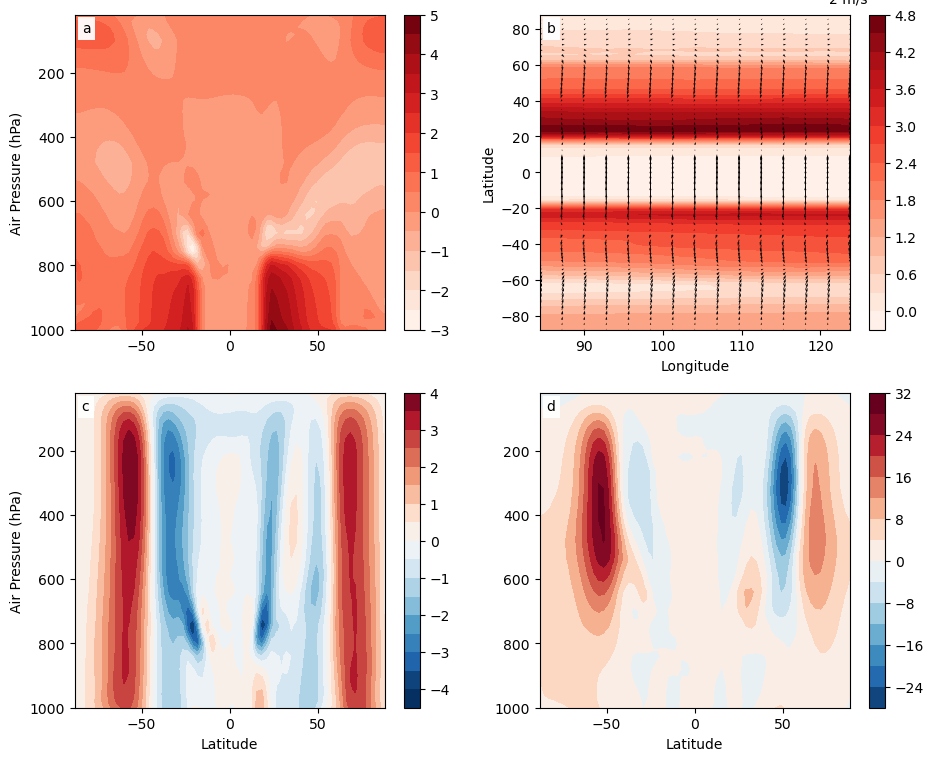

In [11]:
def set_label(fig, ax, label):
    trans = mtransforms.ScaledTranslation(5/72, -5/72, fig.dpi_scale_trans)
    ax.text(0.0, 1.0, label, transform=ax.transAxes + trans,
            fontsize='medium', verticalalignment='top', fontfamily=None,
            bbox=dict(facecolor='1', edgecolor='none', pad=3.0, alpha=0.95))

#fig, axes = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)
gs = gridspec.GridSpec(2, 2)
fig=pl.figure(figsize=(11,9))
ax1 = pl.subplot(gs[0, 0])
ax2 = pl.subplot(gs[0, 1]) 
ax3 = pl.subplot(gs[1, 0])
ax4 = pl.subplot(gs[1, 1])

################# air temperature #########################################
temp = clim['air_temperature'].mean(dim=('lon')) - base_clim['air_temperature'].mean(dim=('lon'))
lat = temp['lat']
pressure = temp['lev']/100
contourf = ax1.contourf(lat, pressure, temp, cmap='Reds', levels=15)
cbar = fig.colorbar(contourf, ax=ax1)
ax1.invert_yaxis()
ax1.set_ylabel('Air Pressure (hPa)')
set_label(fig,ax1, 'a')


################ surface winds ############################################
clim_temp = clim['air_temperature'] -  base_clim['air_temperature']
clim_zonal = clim['eastward_wind'] - base_clim['eastward_wind']
clim_merid = clim['northward_wind'] - base_clim['eastward_wind']

cs = ax2.contourf(
    clim_temp['lon'][30:45],
    clim_temp['lat'],
    clim_temp[0][:,30:45],
    levels=16,
    cmap='Reds')

#ax2.add_patch(Rectangle((84.375, 20), 39.375, 40, fill=True, color='white', alpha=0.3))
#ax2.add_patch(Rectangle((84.375, -60), 39.375, 40, fill=True, color='white', alpha=0.3))

qv = ax2.quiver(
    clim_temp['lon'][30:45],
    clim_temp['lat'],
    clim_zonal[0][:,30:45],
    clim_merid[0][:,30:45],
)

cbar = fig.colorbar(cs, ax=ax2)
ax2.set_ylabel('Latitude')
ax2.set_xlabel('Longitude')


ax2.quiverkey(
    qv,                      
    X=0.9, Y=1.05,           
    U=2,                   
    label='2 m/s',         
    labelpos='E',           
    coordinates='axes'      
)
set_label(fig,ax2, 'b')

######################### zonal winds #####################################
u_clim = clim['eastward_wind'].mean(dim=('lon')) - base_clim['eastward_wind'].mean(dim=('lon'))
lat = u_clim['lat']
pressure = u_clim['lev']/100

up = float(u_clim.max().compute())
down = abs(float(u_clim.min().compute()))
lim=max(up,down)

contourf = ax3.contourf(lat, pressure, u_clim, cmap='RdBu_r',vmin=-lim, vmax=lim, levels=16)
cbar = fig.colorbar(contourf, ax=ax3)
ax3.invert_yaxis()
ax3.set_ylabel('Air Pressure (hPa)')
ax3.set_xlabel('Latitude')
set_label(fig,ax3, 'c')

################## meridional winds #######################################
#v_clim = ds['northward_wind'].var(dim= 'time').mean(dim='lon') - base_ds['northward_wind'].var(dim= 'time').mean(dim='lon')
lat = v_clim['lat']
pressure = v_clim['lev']/100

up = float(v_clim.max().compute())
down = abs(float(v_clim.min().compute()))
lim=max(up,down)

contourf = ax4.contourf(lat, pressure, v_clim, cmap='RdBu_r',vmin=-lim, vmax=lim, levels=16)
cbar = fig.colorbar(contourf, ax=ax4)
ax4.invert_yaxis()
ax4.set_xlabel('Latitude')
set_label(fig,ax4, 'd')


#fig.savefig('/home/data/lab_project2/Steve/model_runs/plotting/dl-plots/2.pdf', bbox_inches='tight')
#fig.savefig('/home/data/lab_project2/Steve/model_runs/plotting/dl-plots/2.jpg',dpi=600, bbox_inches='tight')